# 02 - MLP, APIs and Training Workflows
This notebook explains how to build, compile, and train Multi-Layer Perceptron (MLP) models using Keras. It covers different Keras APIs (Sequential, Functional), model compilation (loss, optimizer, metrics), and training workflows including validation, callbacks (EarlyStopping, ModelCheckpoint, TensorBoard), learning-rate strategies, and evaluation. The focus is on understanding end-to-end MLP training best practices for supervised learning tasks.

## Regression MLP 
Let's load split and scale the California housing dataset

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

housing = fetch_california_housing()

x_train_full, x_test, y_train_full, y_test = train_test_split(
    housing.data,
    housing.target,
    random_state = 42)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_full, y_train_full, random_state = 42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_valid = scaler.transform(x_valid)
x_test = scaler.transform(x_test)

In [2]:
import numpy as np
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
from tensorflow import keras
model = keras.models.Sequential([
    keras.layers.Input(shape=x_train.shape[1:]),
    keras.layers.Dense(30, activation='relu'), 
    keras.layers.Dense(1)
])

model.compile(loss="mean_squared_error",
             optimizer = keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_valid, y_valid))
mse_test = model.evaluate(x_test, y_test)
x_new = x_test[:3]
y_pred = model.predict(x_new)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.7850 - val_loss: 1.0533
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7470 - val_loss: 0.6715
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6544 - val_loss: 0.6150
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6064 - val_loss: 0.5748
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5714 - val_loss: 0.5426
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5439 - val_loss: 0.5161
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5219 - val_loss: 0.4945
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5041 - val_loss: 0.4773
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4896 - val_loss: 0.4636
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4777 - val_loss: 0.4528
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4680 - val_loss: 0.4443
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

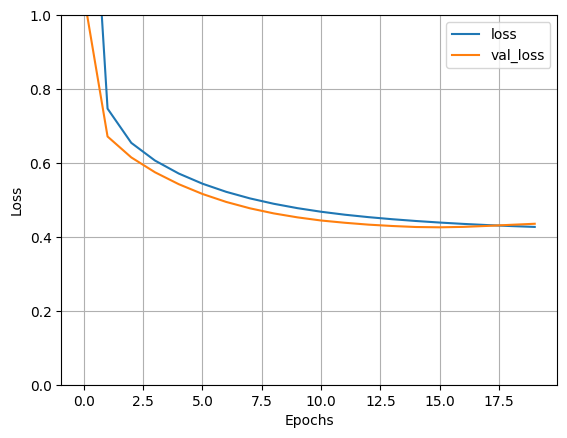

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
pd.DataFrame(history.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.gca().set_ylim(0, 1)
plt.grid(True)

In [5]:
y_pred

array([[0.6602081],
       [1.6080892],
       [3.4692364]], dtype=float32)

## Functional API
Not all neural network models are simply sequential. Some may have complex topologies. Some may have multiple inputs and/or multiple outputs. For example, a Wide & Deep neural network (see paper) connects all or part of the inputs directly to the output layer.

In [6]:
np.random.seed(42)
tf.random.set_seed(42)

In [7]:
input_ = keras.layers.Input(shape=x_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input_], outputs=[output])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 8)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 30)                │             270 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 30)                │             930 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 38)                │               0 │ input_layer_1[0][0],       │
│                               │                           │                 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 1)                 │              39 │ concatenate[0][0]          │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,239 (4.84 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(x_train, x_train, epochs=20,
                    validation_data=(x_valid, y_valid))
mse_test = model.evaluate(x_test, y_test)
y_pred = model.predict(x_new)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.1621 - val_loss: 6.9543
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9631 - val_loss: 7.4027
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9268 - val_loss: 7.1727
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9162 - val_loss: 7.1425
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9119 - val_loss: 7.0951
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9094 - val_loss: 7.0719
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9076 - val_loss: 7.0557
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9061 - val_loss: 7.0432
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9048 - val_loss: 7.0323
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9037 - val_loss: 7.0234
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9027 - val_loss: 7.0154
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

In [9]:
y_pred

array([[-0.15576819],
       [-0.12725936],
       [ 0.07912069]], dtype=float32)

What if you want to send different subsets of input features through the wide or deep paths? We will send 5 features (features 0 to 4), and 6 through the deep path (features 2 to 7). Note that 3 features will go through both (features 2, 3 and 4).

In [10]:
np.random.seed(42)
tf.random.set_seed(42)

In [11]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="output")(concat)
model = keras.models.Model(inputs=[input_A, input_B], outputs=[output])

In [12]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

x_train_A, x_train_B = x_train[:, :5], x_train[:, 2:]
x_valid_A, x_valid_B = x_valid[:, :5], x_valid[:, 2:]
x_test_A, x_test_B = x_test[:, :5], x_test[:, 2:]
x_new_A, x_new_B = x_test_A[:3], x_test_B[:3]

history = model.fit((x_train_A, x_train_B), y_train, epochs=20,
                   validation_data=((x_valid_A, x_valid_B), y_valid))
msE_test = model.evaluate((x_test_A, x_test_B), y_test)
y_pred = model.predict((x_new_A, x_new_B))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.4368 - val_loss: 1.1365
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.9112 - val_loss: 0.7897
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7281 - val_loss: 0.6787
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6582 - val_loss: 0.6196
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6161 - val_loss: 0.5798
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5842 - val_loss: 0.5488
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5573 - val_loss: 0.5226
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5339 - val_loss: 0.5003
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5142 - val_loss: 0.4825
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4984 - val_loss: 0.4696
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4860 - val_loss: 0.4591
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Adding an auxiliary output for regularization:

In [13]:
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="main_output")(concat)
aux_output = keras.layers.Dense(1, name="aux_output")(hidden2)
model = keras.models.Model(inputs=[input_A, input_B],
                           outputs=[output, aux_output])

In [15]:
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit([x_train_A, x_train_B], [y_train, y_train], epochs=20,
                    validation_data=([x_valid_A, x_valid_B], [y_valid, y_valid]))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - aux_output_loss: 4.9489 - loss: 3.0050 - main_output_loss: 2.7884 - val_aux_output_loss: 9.7563 - val_loss: 2.8489 - val_main_output_loss: 2.0804
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - aux_output_loss: 3.3564 - loss: 1.1943 - main_output_loss: 0.9542 - val_aux_output_loss: 10.0075 - val_loss: 1.7328 - val_main_output_loss: 0.8128
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - aux_output_loss: 2.4778 - loss: 0.9210 - main_output_loss: 0.7481 - val_aux_output_loss: 10.2864 - val_loss: 1.6260 - val_main_output_loss: 0.6631
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - aux_output_loss: 2.0329 - loss: 0.8111 - main_output_loss: 0.6755 - val_aux_output_loss: 10.0627 - val_loss: 1.5590 - val_main_output_loss: 0.6135
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - aux_output_loss: 1.7854 - loss: 0.7451 - main_output_loss: 0.6297 - val_aux_output_loss: 9.4821 - val_loss: 1.4721 - val_main_output_loss: 0.58

In [16]:
total_loss, main_loss, aux_loss = model.evaluate(
    [x_test_A, x_test_B], [y_test, y_test])
y_pred_main, y_pred_aux = model.predict([x_new_A, x_new_B])

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - aux_output_loss: 1.0489 - loss: 0.4838 - main_output_loss: 0.4213  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step


## The subclassing API

In [17]:
class WideAndDeepModel(keras.models.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)

    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = keras.layers.concatenate([input_A, hidden2])
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return main_output, aux_output

model = WideAndDeepModel(30, activation="relu")

In [18]:
x_train_A = np.array(x_train_A)
x_train_B = np.array(x_train_B)
x_valid_A = np.array(x_valid_A)
x_valid_B = np.array(x_valid_B)
x_test_A  = np.array(x_test_A)
x_test_B  = np.array(x_test_B)

y_train = np.array(y_train)
y_valid = np.array(y_valid)
y_test  = np.array(y_test)

model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1],
              optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit((x_train_A, x_train_B), (y_train, y_train), epochs=10,
                   validation_data=((x_valid_A, x_valid_B), (y_valid, y_valid)))
total_loss, main_loss, aux_loss = model.evaluate((x_test_A, x_test_B), (y_test, y_test))
y_pred_main, y_pred_aux = model.predict((x_test_A, x_test_B))

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.2811 - mse_loss: 3.7219 - val_loss: 4.1508 - val_mse_loss: 4.9760
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.0672 - mse_loss: 2.3661 - val_loss: 2.0595 - val_mse_loss: 5.2676
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.8288 - mse_loss: 1.8417 - val_loss: 1.3836 - val_mse_loss: 5.2937
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7268 - mse_loss: 1.6063 - val_loss: 1.1075 - val_mse_loss: 4.9743
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6688 - mse_loss: 1.4822 - val_loss: 0.9532 - val_mse_loss: 4.5436
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.6299 - mse_loss: 1.4022 - val_loss: 0.8522 - val_mse_loss: 4.0005
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6026 - mse_loss: 1.3425 - val_loss: 0.7773 - val_mse_loss: 3.4665
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5815 - mse_loss: 1.2937 - val_loss: 0.7167

## Saving and Restoring

In [19]:
np.random.seed(42)
tf.random.set_seed(42)

In [20]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_valid, y_valid))
mse_test = model.evaluate(x_test, y_test)

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.5955 - val_loss: 0.7370
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6698 - val_loss: 0.6250
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6023 - val_loss: 0.5804
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5560 - val_loss: 0.5335
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5214 - val_loss: 0.4956
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4958 - val_loss: 0.4673
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4768 - val_loss: 0.4467
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4623 - val_loss: 0.4315
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4507 - val_loss: 0.4201
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4413 - val_loss: 0.4115
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4316 


In [21]:
model.save("my_keras_model.keras")  
model = keras.models.load_model("my_keras_model.keras")

In [22]:
X_new = np.array(x_new)
y_pred = model.predict(X_new)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


array([[0.503813 ],
       [1.6095974],
       [3.32452  ]], dtype=float32)

In [23]:
model.save_weights("my_keras_weights.weights.h5")
model.load_weights("my_keras_weights.weights.h5")

## Using Callbacks during Training

In [24]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input(shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])

In [25]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.keras", save_best_only=True)

history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_valid, y_valid),
                    callbacks=[checkpoint_cb])
model = keras.models.load_model("my_keras_model.keras") # rollback to best model
mse_test = model.evaluate(x_test, y_test)

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.8524 - val_loss: 0.7689
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6735 - val_loss: 0.6017
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6039 - val_loss: 0.5653
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5679 - val_loss: 0.5305
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5388 - val_loss: 0.5000
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5143 - val_loss: 0.4726
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4936 - val_loss: 0.4534
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4763 - val_loss: 0.4392
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4621 - val_loss: 0.4282
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4503 - val_loss: 0.4209
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4351   


In [26]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
                                                  restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=100,
                    validation_data=(x_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb])
mse_test = model.evaluate(x_test, y_test)

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4405 - val_loss: 0.4169
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4322 - val_loss: 0.4147
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4253 - val_loss: 0.4137
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4195 - val_loss: 0.4133
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4144 - val_loss: 0.4127
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4098 - val_loss: 0.4124
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4056 - val_loss: 0.4122
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4019 - val_loss: 0.4114
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3985 - val_loss: 0.4102
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3954 - val_loss: 0.4083
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3926 - val_loss: 0.4068
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━━

In [27]:
class PrintValTrainRatioCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        print("\nval/train: {:.2f}".format(logs["val_loss"] / logs["loss"]))

In [28]:
val_train_ratio_cb = PrintValTrainRatioCallback()
history = model.fit(x_train, y_train, epochs=1,
                    validation_data=(x_valid, y_valid),
                    callbacks=[val_train_ratio_cb])

358/363 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3369
val/train: 1.01
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3268 - val_loss: 0.3314


## TensorBoard

In [29]:
import os
root_logdir = os.path.join(os.curdir,  "my_logs")
print(root_logdir)

.\my_logs


In [30]:
def get_run_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d_%H_%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()
run_logdir

'.\\my_logs\\run_2025_12_20_18_37_28'

In [31]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [32]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

In [33]:
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = model.fit(x_train, y_train, epochs=30,
                    validation_data=(x_valid, y_valid),
                    callbacks=[checkpoint_cb, tensorboard_cb])

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.7850 - val_loss: 0.8041
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7184 - val_loss: 0.6381
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.6336 - val_loss: 0.5762
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5861 - val_loss: 0.5358
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5524 - val_loss: 0.5057
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5270 - val_loss: 0.4833
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.5073 - val_loss: 0.4657
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4915 - val_loss: 0.4516
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4783 - val_loss: 0.4400
Epoch 10/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4671 - val_loss: 0.4302
Epoch 11/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4574 - val_loss: 0.4215
Epoch 12/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

To start the TensorBoard server, one option is to open a terminal, if needed activate the virtualenv where you installed TensorBoard, go to this notebook's directory, then type:

$ tensorboard --logdir=./my_logs --port=6006
You can then open your web browser to localhost:6006 and use TensorBoard. Once you are done, press Ctrl-C in the terminal window, this will shutdown the TensorBoard server.

Alternatively, you can load TensorBoard's Jupyter extension and run it like this:

In [34]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs --port=6006

Reusing TensorBoard on port 6006 (pid 20520), started 19:56:47 ago. (Use '!kill 20520' to kill it.)

In [35]:
run_logdir2 = get_run_logdir()
run_logdir2

'.\\my_logs\\run_2025_12_20_18_38_43'

In [36]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [37]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=0.05))

In [38]:
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir2)
history = model.fit(x_train, y_train, epochs=30,
                    validation_data=(x_valid, y_valid),
                    callbacks=[checkpoint_cb, tensorboard_cb])

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.7058 - val_loss: 19.5494
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.5841 - val_loss: 347.7899
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4387 - val_loss: 0.9989
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3954 - val_loss: 400.8587
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3774 - val_loss: 0.3773
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3533 - val_loss: 0.3302
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3370 - val_loss: 0.3328
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3305 - val_loss: 0.4601
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3263 - val_loss: 0.4290
Epoch 10/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3219 - val_loss: 0.3231
Epoch 11/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3176 - val_loss: 0.3219
Epoch 12/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms

In [39]:
help(keras.callbacks.TensorBoard.__init__)

Help on function __init__ in module keras.src.callbacks.tensorboard:

__init__(
    self,
    log_dir='logs',
    histogram_freq=0,
    write_graph=True,
    write_images=False,
    write_steps_per_second=False,
    update_freq='epoch',
    profile_batch=0,
    embeddings_freq=0,
    embeddings_metadata=None
)
    Initialize self.  See help(type(self)) for accurate signature.



##  Hyperparameter Tuning

In [40]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [41]:
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[8]):
    model= keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="mse", optimizer=optimizer)
    return model

In [42]:
from scikeras.wrappers import KerasRegressor
keras_reg = KerasRegressor(model = build_model)

keras_reg.fit(x_train, y_train, epochs=100,
              validation_data=(x_valid, y_valid),
              callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.3617 - val_loss: 7.1124
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6120 - val_loss: 2.2587
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5014 - val_loss: 0.5016
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4609 - val_loss: 0.4667
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4417 - val_loss: 0.4202
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4306 - val_loss: 0.4236
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4215 - val_loss: 0.4182
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4158 - val_loss: 0.4161
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4109 - val_loss: 0.4130
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4069 - val_loss: 0.4107
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4036 - val_loss: 0.4085
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━━

,model,<function bui...002B2CB41B1A0>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,None
,validation_batch_size,None
,verbose,1
,callbacks,None


In [43]:
mse_test = keras_reg.score(x_test, y_test)
mse_test

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step   


0.7400123691095013

In [44]:
y_pred = keras_reg.predict(x_new)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


array([0.48674673, 1.6566727 , 4.2461166 ], dtype=float32)

In [45]:
np.random.seed(42)
tf.random.set_seed(42)

In [46]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

param_distribs = {
    "model__n_hidden": [0, 1, 2, 3],
    "model__n_neurons": np.arange(1, 100).tolist(),
    "model__learning_rate": reciprocal(3e-4, 3e-2),
}

rnd_search_cv = RandomizedSearchCV(
    keras_reg,
    param_distribs,
    n_iter=10,
    cv=3,
    verbose=2
)

rnd_search_cv.fit(
    x_train, y_train,
    validation_data=(x_valid, y_valid),
    callbacks=[keras.callbacks.EarlyStopping(patience=10)]
)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.6885 - val_loss: 2.1195
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
[CV] END model__learning_rate=0.0016834549246003507, model__n_hidden=0, model__n_neurons=15; total time=   2.6s
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.0016 - val_loss: 23.3362
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
[CV] END model__learning_rate=0.0016834549246003507, model__n_hidden=0, model__n_neurons=15; total time=   2.8s
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.5830 - val_loss: 1.7954
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step   
[CV] END model__learning_rate=0.0016834549246003507, model__n_hidden=0, model__n_neurons=15; total time=   3.1s
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.4613 - val_loss: 7.8808
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
[CV] END model__learning_rate=0.008731907739399207, model__n_hidden=0, model__n_neurons=21; total time=   3.0s
242/242 ━━━━━━━━━━

,estimator,KerasRegresso...se epochs=1 )
,param_distributions,"{'model__learning_rate': <scipy.stats....002B28799A510>, 'model__n_hidden': [0, 1, ...], 'model__n_neurons': [1, 2, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [47]:
rnd_search_cv.best_params_

{'model__learning_rate': np.float64(0.0051532863337015134),
 'model__n_hidden': 1,
 'model__n_neurons': 22}

In [48]:
rnd_search_cv.best_score_

np.float64(0.5447046952316622)

In [49]:
rnd_search_cv.best_estimator_

,model,<function bui...002B2CB41B1A0>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,None
,validation_batch_size,None
,verbose,1
,callbacks,None


In [50]:
rnd_search_cv.score(x_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step   


0.5990547403765949

In [51]:
best_est = rnd_search_cv.best_estimator_

keras_model = best_est.model_
keras_model.evaluate(x_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5305  


0.5305379033088684

In [52]:
keras_model.summary()
keras_model.predict(x_test)

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                     │ (None, 22)                  │             198 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_69 (Dense)                     │ (None, 1)                   │              23 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 223 (896.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


array([[0.77269334],
       [1.3417711 ],
       [3.0186388 ],
       ...,
       [1.4468281 ],
       [2.7453065 ],
       [3.4605155 ]], shape=(5160, 1), dtype=float32)

## Exercise
Exercise: Train a deep MLP on the MNIST dataset (you can load it using keras.datasets.mnist.load_data(). See if you can get over 98% precision. Try searching for the optimal learning rate by using the approach presented in this chapter (i.e., by growing the learning rate exponentially, plotting the loss, and finding the point where the loss shoots up). Try adding all the bells and whistles—save checkpoints, use early stopping, and plot learning curves using TensorBoard.

In [53]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

Just like for the Fashion MNIST dataset, the MNIST training set contains 60,000 grayscale images, each 28x28 pixels:

In [54]:
x_train_full.shape

(60000, 28, 28)

Each pixel intensity is also represented as a byte (0 to 255):

In [55]:
x_train_full.dtype

dtype('uint8')

Let's split the full training set into a validation set and a (smaller) training set. We also scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255, just like we did for Fashion MNIST:

In [56]:
x_valid, x_train = x_train_full[:5000] / 255, x_train_full[5000:] / 255
y_valid, y_train = y_train_full[:5000] , y_train_full[5000:] 
x_test = x_test / 255 

Let's plot an image using Matplotlib's imshow() function, with a 'binary' color map:

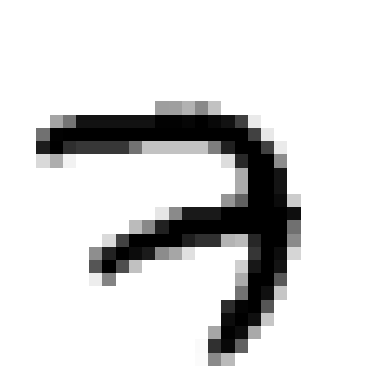

In [57]:
plt.imshow(x_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9. Conveniently, the class IDs correspond to the digits represented in the images, so we don't need a class_names arr

In [58]:
y_train

array([7, 3, 4, ..., 5, 6, 8], shape=(55000,), dtype=uint8)

The validation set contains 5,000 images, and the test set contains 10,000 images:

In [59]:
x_valid.shape

(5000, 28, 28)

Let's take a look at a sample of the images in the dataset:

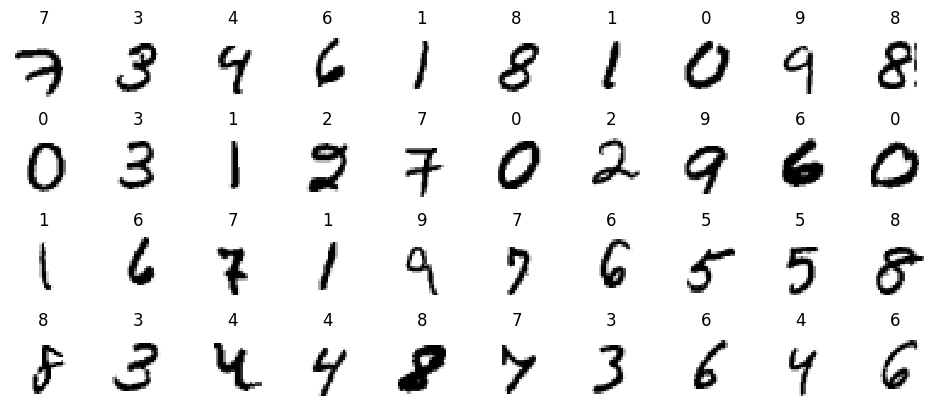

In [60]:
n_row = 4
n_col = 10
plt.figure(figsize=(n_col * 1.2, n_row * 1.2))
for row in range(n_row):
    for col in range(n_col):
        index = n_col * row + col
        plt.subplot(n_row, n_col, index + 1)
        plt.imshow(x_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Let's build a simple dense network and find the optimal learning rate. We will need a callback to grow the learning rate at each iteration. It will also record the learning rate and the loss at each iteration:

In [61]:
class ExponentialLearningRate(keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []
    def on_batch_end(self, batch, logs):
        lr = self.model.optimizer.learning_rate
        lr_value = float(tf.keras.backend.get_value(lr))
        self.rates.append(lr_value)
        self.losses.append(logs["loss"])
        lr.assign(lr_value * self.factor)

In [62]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [63]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

We will start with a small learning rate of 1e-3, and grow it by 0.5% at each iteration:

In [64]:
model.compile(loss="sparse_categorical_crossentropy",
             optimizer = keras.optimizers.SGD(learning_rate=1e-3),
             metrics=["accuracy"])
explon_lr = ExponentialLearningRate(factor=1.005)

Now let's train the model for just 1 epoch:

In [65]:
history = model.fit(x_train, y_train, epochs=1,
                   validation_data=(x_valid, y_valid),
                   callbacks=[explon_lr])

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.5831 - loss: nan - val_accuracy: 0.0958 - val_loss: nan


We can now plot the loss as a function of the learning rate:

Text(0, 0.5, 'Loss')

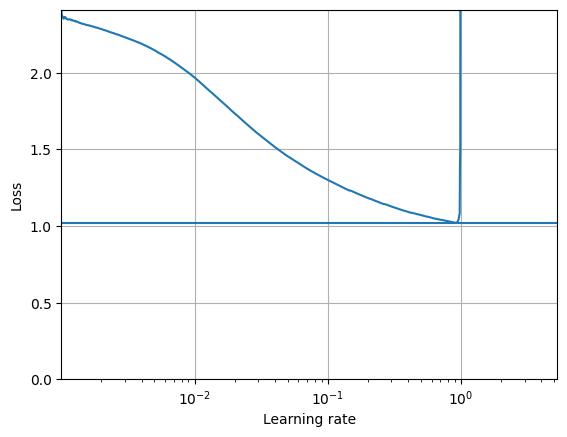

In [66]:
plt.plot(explon_lr.rates, explon_lr.losses)
plt.gca().set_xscale('log')
plt.hlines(min(explon_lr.losses), min(explon_lr.rates), max(explon_lr.rates))
plt.axis([min(explon_lr.rates), max(explon_lr.rates), 0, explon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

The loss starts shooting back up violently when the learning rate goes over 6e-1, so let's try using half of that, at 3e-1:

In [67]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [68]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [69]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=3e-1),
              metrics=["accuracy"])

In [70]:
run_index = 1 # increment this at every run
run_logdir = os.path.join(os.curdir, "my_mnist_logs", "run_{:03d}".format(run_index))
run_logdir

'.\\my_mnist_logs\\run_001'

In [71]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=20)
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

history = model.fit(x_train, y_train, epochs=100,
                    validation_data=(x_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9273 - loss: 0.2346 - val_accuracy: 0.9634 - val_loss: 0.1202
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9727 - loss: 0.0912 - val_accuracy: 0.9752 - val_loss: 0.0862
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9819 - loss: 0.0589 - val_accuracy: 0.9768 - val_loss: 0.0828
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9865 - loss: 0.0423 - val_accuracy: 0.9774 - val_loss: 0.0902
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9887 - loss: 0.0343 - val_accuracy: 0.9782 - val_loss: 0.0854
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9913 - loss: 0.0263 - val_accuracy: 0.9778 - val_loss: 0.0874
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9931 - loss: 0.0214 - val_accuracy: 0.9810 - val_loss: 0.0845
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9932 -

In [72]:
model = keras.models.load_model("my_mnist_model.keras") 
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9752 - loss: 0.0838


[0.08380474150180817, 0.9751999974250793]

We got over 97% accuracy. Finally, let's look at the learning curves using TensorBoard:

In [73]:
%tensorboard --logdir=./my_mnist_logs --port=6006

Reusing TensorBoard on port 6006 (pid 10552), started 1:05:27 ago. (Use '!kill 10552' to kill it.)